In [14]:
import h3
import geopandas
import h3pandas
from shapely.geometry import Polygon
# import plotly.figure_factory as ff
import plotly.express as px

import contextily as cx
import matplotlib.pyplot as plt


In [15]:
def plot_df(df, column=None, ax=None):
    "Plot based on the `geometry` column of a GeoPandas dataframe"
    df = df.copy()
    df = df.to_crs(epsg=3857)  # web mercator

    if ax is None:
        _, ax = plt.subplots(figsize=(8,8))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    df.plot(
        ax=ax,
        alpha=0.5, edgecolor='k',
        column=column, categorical=True,
        legend=True, legend_kwds={'loc': 'upper left'},
    )
    cx.add_basemap(ax, crs=df.crs, source=cx.providers.CartoDB.Positron)


def plot_shape(shape, ax=None):
    df = geopandas.GeoDataFrame({'geometry': [shape]}, crs='EPSG:4326')
    plot_df(df, ax=ax)


def plot_cells(cells, ax=None):
    shape = h3.cells_to_h3shape(cells)
    plot_shape(shape, ax=ax)


def plot_shape_and_cells(shape, res=9):
    fig, axs = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
    plot_shape(shape, ax=axs[0])
    plot_cells(h3.h3shape_to_cells(shape, res), ax=axs[1])
    fig.tight_layout()

In [16]:
wssc_path = "/home/emmaf/Documents/Data269/WSSCAlertsScraper/outputs/wssc_alerts_geocoded.shp"
wssc_alerts = geopandas.read_file(wssc_path)
wssc_alerts.head()

,title,date,pipe_diam,address,full_text,geometry
0,Emergency Water Main Repair - Takoma Park,"December 30, 2022",8.0,"602 Ethan Allen Avenue, Takoma Park, Maryland,...","Laurel, MD â December 30, 2022: WSSC Water i...",POINT (-76.99652 38.97612)
1,Emergency Water Main Repair - Oxon Hill,"December 29, 2022",8.0,"801 Owens Road, Oxon Hill, Maryland, USA","Laurel, MD â December 29, 2022: WSSC Water i...",POINT (-76.99568 38.82493)
2,Emergency Water Main Repair - Greenbelt,"December 28, 2022",10.0,"9115 Springhill Ln, Greenbelt, Maryland, USA","Laurel, MD â December 28, 2022: WSSC Water i...",POINT (-76.90314 39.00265)
3,Emergency Water Main Repair - Gaithersburg,"December 26, 2022",12.0,"16 Chestnut St, Gaithersburg, Maryland, USA","Laurel, MD â December 26, 2022: WSSC Water i...",POINT (-77.20224 39.14322)
4,Emergency Water Main Repair - North Bethesda,"December 22, 2022",16.0,"10900 Rockville Pike, North Bethesda, Maryland...","Laurel, MD â December 22, 2022: WSSC Water i...",POINT (-77.10956 39.03356)


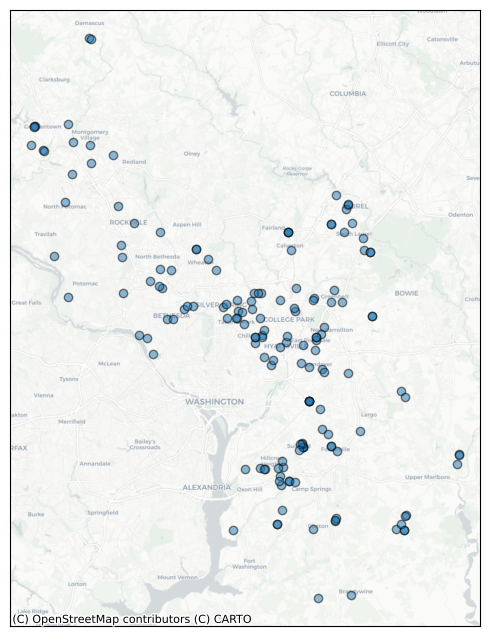

In [17]:
plot_df(wssc_alerts)

In [18]:
def assign_h3(df, resolution):
    df[f'h3_{resolution}'] = df.apply(lambda row: h3.latlng_to_cell(float(row["geometry"].y), float(row['geometry'].x), resolution), axis=1)
    
# addr_df = pd.DataFrame.spatial.from_featureclass(r'H3\H3.gdb\address_points_20220727_wgs84')


# res = 10 # Trial and error suggests that this is the smallest resolution that doesn't result in alerts for distinct locations (i.e.: lat/lon are unique) ending up in the same hex
res = 7
%timeit assign_h3(wssc_alerts, res)
count_h3 = wssc_alerts.value_counts(f"h3_{res}")
count_h3
# wssc_alerts.head()


2.85 ms ± 116 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


h3_7
872aa8716ffffff    7
872aa8473ffffff    5
872aa8472ffffff    5
872aa8463ffffff    5
872aa8571ffffff    4
                  ..
872aa8099ffffff    1
872aa8788ffffff    1
872aa8591ffffff    1
872aa8468ffffff    1
872aa8464ffffff    1
Name: count, Length: 86, dtype: int64

In [19]:
cell_list = wssc_alerts[f"h3_{res}"].unique()
cell_list

<ArrowStringArray>
['872aa8473ffffff', '872aa87a3ffffff', '872aa8559ffffff', '872aa859dffffff',
 '872aa841cffffff', '872aae2e9ffffff', '872aaa96dffffff', '872aa8413ffffff',
 '872aa8716ffffff', '872aa855effffff', '872aa8409ffffff', '872aa8571ffffff',
 '872aa8592ffffff', '872aa84f4ffffff', '872aa848cffffff', '872aa87acffffff',
 '872aa854bffffff', '872aa872bffffff', '872aa84e2ffffff', '872aa84a6ffffff',
 '872aa8418ffffff', '872aa8605ffffff', '872aa87a1ffffff', '872aa8712ffffff',
 '872aa8475ffffff', '872aa844cffffff', '872aa8719ffffff', '872aa854affffff',
 '872aa8440ffffff', '872aa8442ffffff', '872aa8444ffffff', '872aa8541ffffff',
 '872aa8474ffffff', '872aa8480ffffff', '872aa8550ffffff', '872aa87a9ffffff',
 '872aa871dffffff', '872aa8460ffffff', '872aa8476ffffff', '872aa846dffffff',
 '872aa84e6ffffff', '872aa8472ffffff', '872aa8466ffffff', '872aa8583ffffff',
 '872aa8410ffffff', '872aa8545ffffff', '872aa870dffffff', '872aa80d0ffffff',
 '872aa840bffffff', '872aa8733ffffff', '872aa8446ffffff',

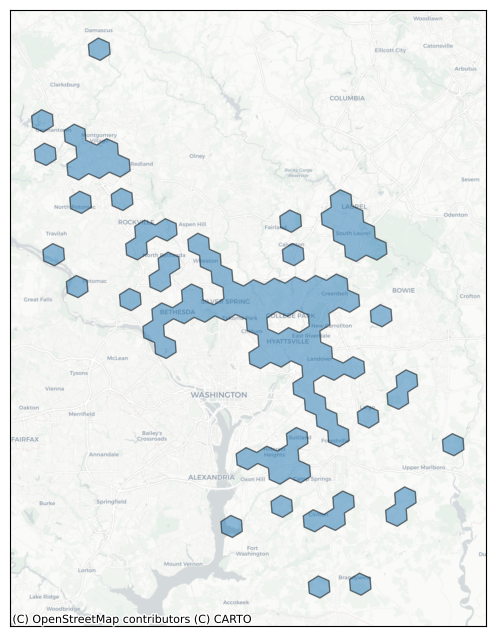

In [20]:
# cells = ['8a2aa8473587fff',
#  '8a2aa87a3077fff',
#  '8a2aa8466927fff',
#  '8a2aa859d10ffff',
#  '8a2aa841c0dffff',
#  '8a2aae2e9c47fff',
#  '8a2aaa96db37fff',
#  '8a2aa8413517fff',
#  '8a2aa8716baffff',
#  '8a2aa855ec77fff',
#  '8a2aaa96db27fff',
#  '8a2aa84098b7fff',
#  '8a2aa8571ac7fff',
#  '8a2aa8592267fff',
#  '8a2aa84f4d2ffff',
#  '8a2aa848c21ffff',
#  '8a2aa87ac99ffff',
#  '8a2aaa96dc1ffff',
#  '8a2aa8571c8ffff',
#  '8a2aa841caeffff',
#  '8a2aa8446d87fff',
#  '8a2aa857134ffff',
#  '8a2aa8473b57fff',
#  '8a2aa859220ffff',
#  '8a2aa854b407fff',
#  '8a2aa872b74ffff',
#  '8a2aa84e240ffff',
#  '8a2aa84a6447fff',
#  '8a2aa8418a5ffff',
#  '8a2aa86051a7fff',
#  '8a2aa87a1737fff',
#  '8a2aa8712727fff',
#  '8a2aa8475b5ffff',
#  '8a2aa844dd97fff',
#  '8a2aa8719d2ffff',
#  '8a2aa854a0d7fff',
#  '8a2aa844078ffff',
#  '8a2aa8442957fff',
#  '8a2aa8475b27fff',
#  '8a2aa8418197fff',
#  '8a2aa84441affff',
#  '8a2aa8541b17fff',
#  '8a2aa847436ffff',
#  '8a2aa87a10effff',
#  '8a2aa8480b2ffff',
#  '8a2aa855392ffff',
#  '8a2aa87a974ffff',
#  '8a2aa871d6affff',
#  '8a2aa8460a8ffff',
#  '8a2aa84762affff',
#  '8a2aa846d40ffff',
#  '8a2aa84e6b47fff',
#  '8a2aa84720b7fff',
#  '8a2aa8466907fff',
#  '8a2aa8583407fff',
#  '8a2aa8410d9ffff',
#  '8a2aa8545767fff',
#  '8a2aa870da8ffff',
#  '8a2aa80d002ffff',
#  '8a2aa844dd97fff',
#  '8a2aa840bcb7fff',
#  '8a2aa847262ffff',
#  '8a2aa87337b7fff',
#  '8a2aa87337b7fff',
#  '8a2aa8446ca7fff',
#  '8a2aa8472607fff',
#  '8a2aa87aca97fff',
#  '8a2aa8400337fff',
#  '8a2aa8400337fff',
#  '8a2aa858b347fff',
#  '8a2aa80d0077fff',
#  '8a2aa840cc27fff',
#  '8a2aa8716877fff',
#  '8a2aa87332b7fff',
#  '8a2aa8472007fff',
#  '8a2aa8446487fff',
#  '8a2aa859ccaffff',
#  '8a2aa8712cdffff',
#  '8a2aa855392ffff',
#  '8a2aa8470647fff',
#  '8a2aa84e491ffff',
#  '8a2aa8716baffff',
#  '8a2aa8716baffff',
#  '8a2aa87ac10ffff',
#  '8a2aa8476157fff',
#  '8a2aa871d68ffff',
#  '8a2aa87a974ffff',
#  '8a2aa870d0d7fff',
#  '8a2aa84e344ffff',
#  '8a2aa855b107fff',
#  '8a2aa873209ffff',
#  '8a2aa8540117fff',
#  '8a2aa84136e7fff',
#  '8a2aa862c59ffff',
#  '8a2aa844d8effff',
#  '8a2aa859835ffff',
#  '8a2aa85922effff',
#  '8a2aa8732237fff',
#  '8a2aa8418aaffff',
#  '8a2aa8712797fff',
#  '8a2aa858ed67fff',
#  '8a2aa84637affff',
#  '8a2aa87134f7fff',
#  '8a2aa80d392ffff',
#  '8a2aa87134f7fff',
#  '8a2aa85442b7fff',
#  '8a2aa809d6b7fff',
#  '8a2aa856a7b7fff',
#  '8a2aa856a7b7fff',
#  '8a2aa840112ffff',
#  '8a2aa840daeffff',
#  '8a2aa870da8ffff',
#  '8a2aa854639ffff',
#  '8a2aa854639ffff',
#  '8a2aa84602effff',
#  '8a2aa809459ffff',
#  '8a2aa809459ffff',
#  '8a2aa840a2affff',
#  '8a2aa87a10effff',
#  '8a2aa846adaffff',
#  '8a2aa844505ffff',
#  '8a2aa841500ffff',
#  '8a2aa8409ac7fff',
#  '8a2aa840d64ffff',
#  '8a2aa871685ffff',
#  '8a2aa871bc4ffff',
#  '8a2aa8476b07fff',
#  '8a2aa8713087fff',
#  '8a2aa846e2cffff',
#  '8a2aa855392ffff',
#  '8a2aa873569ffff',
#  '8a2aa84e2057fff',
#  '8a2aa844478ffff',
#  '8a2aa846385ffff',
#  '8a2aa84e4737fff',
#  '8a2aa80999a7fff',
#  '8a2aa87a999ffff',
#  '8a2aa87168c7fff',
#  '8a2aa8788917fff',
#  '8a2aa84732e7fff',
#  '8a2aa84732e7fff',
#  '8a2aa872b66ffff',
#  '8a2aa8476baffff',
#  '8a2aa846334ffff',
#  '8a2aa871606ffff',
#  '8a2aa846382ffff',
#  '8a2aa8571af7fff',
#  '8a2aa8591997fff',
#  '8a2aa846382ffff',
#  '8a2aa846858ffff',
#  '8a2aa8444c2ffff',
#  '8a2aa844c367fff',
#  '8a2aa844c367fff',
#  '8a2aa870d127fff',
#  '8a2aa844055ffff',
#  '8a2aa847049ffff',
#  '8a2aae2e9137fff',
#  '8a2aa84648f7fff']

# l = len(cells)
# print(l)
# print(int(l*(3/8)), int(l*(7/16)))
# print(cells[150:])
# plot_cells(cells[151:])

plot_cells(cell_list)

In [21]:
alert_count_h3 = wssc_alerts.groupby(f"h3_{res}").agg('size').to_frame("count").reset_index()
# h3_geom_col = alert_count_h3[f"h3_{res}"].apply(h3.cells_to_h3shape)
h3_geom_col = alert_count_h3[f"h3_{res}"].apply(lambda row: h3.cells_to_h3shape([row]))
# h3_geom_col
alert_count_h3['geometry'] = h3_geom_col
alert_count_h3 = alert_count_h3.set_geometry("geometry", crs="4326")
alert_count_h3

,h3_7,count,geometry
0,872aa8094ffffff,2,"POLYGON ((-76.8247 38.97391, -76.80971 38.9686..."
1,872aa8099ffffff,1,"POLYGON ((-76.7739 38.89802, -76.78886 38.9032..."
2,872aa809dffffff,1,"POLYGON ((-76.79003 38.9153, -76.78886 38.9032..."
3,872aa80d0ffffff,3,"POLYGON ((-76.72441 38.8342, -76.70947 38.8289..."
4,872aa8400ffffff,2,"POLYGON ((-77.08001 39.0631, -77.07876 39.0510..."
...,...,...,...
81,872aa87a3ffffff,1,"POLYGON ((-77.01147 38.81902, -76.99651 38.813..."
82,872aa87a9ffffff,3,"POLYGON ((-76.93429 38.76889, -76.93549 38.780..."
83,872aa87acffffff,3,"POLYGON ((-76.93912 38.81688, -76.95407 38.822..."
84,872aaa96dffffff,3,"POLYGON ((-77.27719 39.14304, -77.2634 39.1498..."


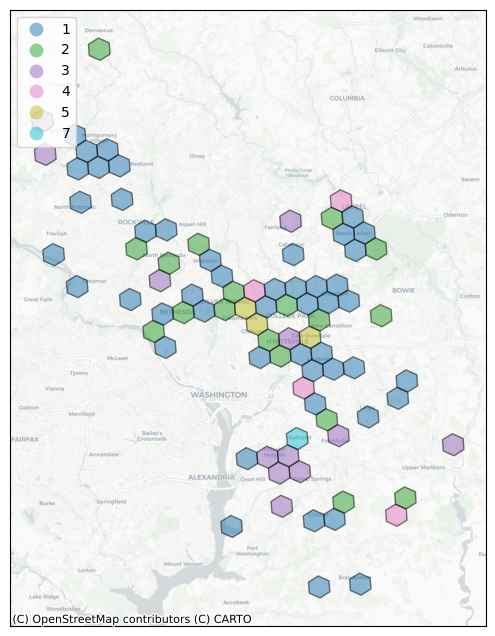

In [22]:
plot_df(alert_count_h3, column="count")
# alert_count_h3.plot()



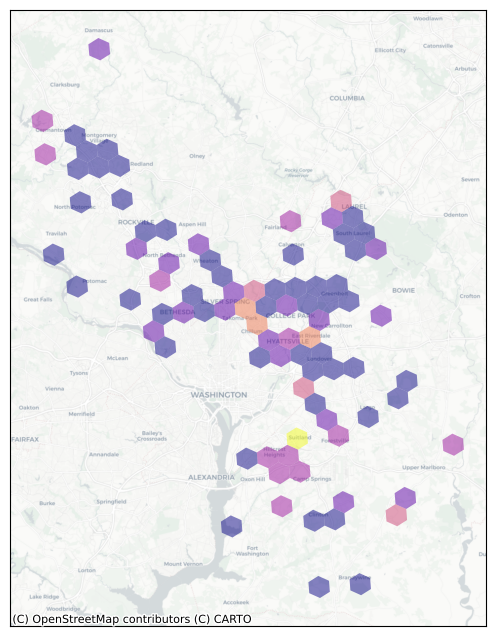

In [23]:
_, ax = plt.subplots(figsize=(8,8))
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

tmp = alert_count_h3.copy()
tmp = tmp.to_crs(epsg=3857)  # web mercator

tmp.plot(
        ax=ax,
        alpha=0.5,
        column="count", cmap="plasma"
    )
cx.add_basemap(ax, crs=tmp.crs, source=cx.providers.CartoDB.Positron)

In [24]:
fig = (px.choropleth_mapbox(
                    alert_count_h3, 
                    # geojson=geojson_obj, 
                    locations=f"h3_{res}", 
                    color='count',
                    color_continuous_scale="viridis",
                    range_color=(0,alert_count_h3['count'].mean()),                  
                    mapbox_style='carto-positron',
                    zoom=7,
                    center = {"lat": 38.9875721, "lon": -76.9393273},
                    opacity=0.7,
                    labels={'count':'# of alerts '}))
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

/tmp/ipykernel_1493353/1618023902.py:1: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = (px.choropleth_mapbox(


In [25]:
alert_count_h3

alert_count_h3_wo_geo = alert_count_h3[[f"h3_{res}", "count"]]

In [26]:
# wssc_alerts_h3_alt = wssc_alerts.h3.

In [27]:
dupe_h3 = count_h3.loc[lambda x: x > 1]
dupe_h3

h3_7
872aa8716ffffff    7
872aa8473ffffff    5
872aa8472ffffff    5
872aa8463ffffff    5
872aa8571ffffff    4
872aa844cffffff    4
872aa8476ffffff    4
872aa870dffffff    4
872aaa96dffffff    3
872aa8592ffffff    3
872aa87acffffff    3
872aa8418ffffff    3
872aa87a1ffffff    3
872aa8712ffffff    3
872aa8444ffffff    3
872aa8550ffffff    3
872aa87a9ffffff    3
872aa80d0ffffff    3
872aa8733ffffff    3
872aa8713ffffff    3
872aa841cffffff    2
872aae2e9ffffff    2
872aa8413ffffff    2
872aa8409ffffff    2
872aa872bffffff    2
872aa84e2ffffff    2
872aa8475ffffff    2
872aa8440ffffff    2
872aa871dffffff    2
872aa8460ffffff    2
872aa8446ffffff    2
872aa8400ffffff    2
872aa84e4ffffff    2
872aa8732ffffff    2
872aa856affffff    2
872aa840dffffff    2
872aa8546ffffff    2
872aa8094ffffff    2
Name: count, dtype: int64

In [28]:
wssc_alerts[wssc_alerts[f'h3_{res}'] == '8a2aa87a10effff']

,title,date,pipe_diam,address,full_text,geometry,h3_7


In [29]:
for idx in dupe_h3.index:
    subset = wssc_alerts[wssc_alerts[f'h3_{res}'] == idx] 
    # subset["address"].unique()
    # if (len(subset) != len(subset["geometry"].unique())):
    print(f"For idx = {idx}:")
    print(f"     count = {len(subset)}")
    print(f"   address = {len(subset["address"].unique())}")
    print(f"  geometry = {len(subset["geometry"].unique())}")
    # print(f"       lon = {len(subset["longitude"].unique())}")
    


For idx = 872aa8716ffffff:
     count = 7
   address = 5
  geometry = 5
For idx = 872aa8473ffffff:
     count = 5
   address = 5
  geometry = 4
For idx = 872aa8472ffffff:
     count = 5
   address = 5
  geometry = 5
For idx = 872aa8463ffffff:
     count = 5
   address = 4
  geometry = 4
For idx = 872aa8571ffffff:
     count = 4
   address = 4
  geometry = 4
For idx = 872aa844cffffff:
     count = 4
   address = 3
  geometry = 2
For idx = 872aa8476ffffff:
     count = 4
   address = 4
  geometry = 4
For idx = 872aa870dffffff:
     count = 4
   address = 4
  geometry = 4
For idx = 872aaa96dffffff:
     count = 3
   address = 3
  geometry = 3
For idx = 872aa8592ffffff:
     count = 3
   address = 3
  geometry = 3
For idx = 872aa87acffffff:
     count = 3
   address = 3
  geometry = 3
For idx = 872aa8418ffffff:
     count = 3
   address = 3
  geometry = 3
For idx = 872aa87a1ffffff:
     count = 3
   address = 3
  geometry = 3
For idx = 872aa8712ffffff:
     count = 3
   address = 3
  geome

In [30]:
hex_grouping = wssc_alerts.groupby(f"h3_{res}").geometry.agg(list).to_frame("geoms").reset_index()
hex_grouping["count"] = hex_grouping["geoms"].apply(lambda g: len(g))
hex_grouping.head()

,h3_7,geoms,count
0,872aa8094ffffff,"[POINT (-76.8254662 38.9842055), POINT (-76.82...",2
1,872aa8099ffffff,[POINT (-76.7814506 38.8995735)],1
2,872aa809dffffff,[POINT (-76.7871032 38.9056588)],1
3,872aa80d0ffffff,"[POINT (-76.7092948 38.8401333), POINT (-76.70...",3
4,872aa8400ffffff,"[POINT (-77.060948 39.053633), POINT (-77.0609...",2


In [31]:
def add_geometry(row):
  points = h3.h3_to_geo_boundary(row[f"h3_{res}"], True)
  return Polygon(points)
#Apply function into our dataframe
hex_grouping['geometry'] = (hex_grouping
                                .apply(add_geometry,axis=1))
                                

AttributeError: module 'h3' has no attribute 'h3_to_geo_boundary'

In [32]:
from geojson import Feature, Point, FeatureCollection, Polygon
import json

def hexagons_dataframe_to_geojson(df_hex, hex_id_field,geometry_field, value_field,file_output = None):

    list_features = []

    for i, row in df_hex.iterrows():
        feature = Feature(geometry = row[geometry_field],
                          id = row[hex_id_field],
                          properties = {"value": row[value_field]})
        list_features.append(feature)

    feat_collection = FeatureCollection(list_features)

    if file_output is not None:
        with open(file_output, "w") as f:
            json.dump(feat_collection, f)

    else :
      return feat_collection

In [33]:
geojson_obj = (hexagons_dataframe_to_geojson
                (hex_grouping,
                 hex_id_field=f"h3_{res}",
                 value_field='count',
                 geometry_field='geometry'))

KeyError: 'geometry'

In [34]:
# # https://plotly.com/python/hexbin-mapbox/

# # df = px.data.carshare()

# fig = ff.create_hexbin_map(
#     data_frame=wssc_alerts, lat="latitude", lon="longitude",
#     nx_hexagon=6, opacity=0.5, labels={"color": "Point Count"},
#     min_count=1, color_continuous_scale="Viridis",
#     show_original_data=True,
#     original_data_marker=dict(size=4, opacity=0.6, color="deeppink")
# )
# fig.show()

fig = (px.choropleth_mapbox(
                    hex_grouping, 
                    geojson=geojson_obj, 
                    locations=f"h3_{res}", 
                    color='count',
                    color_continuous_scale="Viridis",
                    range_color=(0,hex_grouping['count'].mean()),                  
                    mapbox_style='carto-positron',
                    zoom=7,
                    center = {"lat": 38.9875721, "lon": -76.9393273},
                    opacity=0.7,
                    labels={'count':'# of alerts '}))
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

NameError: name 'geojson_obj' is not defined

In [ ]:
px.data.carshare()

,centroid_lat,centroid_lon,car_hours,peak_hour
0,45.471549,-73.588684,1772.750000,2
1,45.543865,-73.562456,986.333333,23
2,45.487640,-73.642767,354.750000,20
3,45.522870,-73.595677,560.166667,23
4,45.453971,-73.738946,2836.666667,19
...,...,...,...,...
244,45.547171,-73.556258,951.416667,3
245,45.546482,-73.574939,795.416667,2
246,45.495523,-73.627725,425.750000,8
247,45.521199,-73.581789,1044.833333,17


In [36]:
wssc_alerts_alt = geopandas.read_file(wssc_path)
wssc_alerts_alt.head()

,title,date,pipe_diam,address,full_text,geometry
0,Emergency Water Main Repair - Takoma Park,"December 30, 2022",8.0,"602 Ethan Allen Avenue, Takoma Park, Maryland,...","Laurel, MD â December 30, 2022: WSSC Water i...",POINT (-76.99652 38.97612)
1,Emergency Water Main Repair - Oxon Hill,"December 29, 2022",8.0,"801 Owens Road, Oxon Hill, Maryland, USA","Laurel, MD â December 29, 2022: WSSC Water i...",POINT (-76.99568 38.82493)
2,Emergency Water Main Repair - Greenbelt,"December 28, 2022",10.0,"9115 Springhill Ln, Greenbelt, Maryland, USA","Laurel, MD â December 28, 2022: WSSC Water i...",POINT (-76.90314 39.00265)
3,Emergency Water Main Repair - Gaithersburg,"December 26, 2022",12.0,"16 Chestnut St, Gaithersburg, Maryland, USA","Laurel, MD â December 26, 2022: WSSC Water i...",POINT (-77.20224 39.14322)
4,Emergency Water Main Repair - North Bethesda,"December 22, 2022",16.0,"10900 Rockville Pike, North Bethesda, Maryland...","Laurel, MD â December 22, 2022: WSSC Water i...",POINT (-77.10956 39.03356)


In [37]:
wssc_alerts_alt = wssc_alerts_alt.h3.geo_to_h3(res).reset_index()
wssc_alerts_alt.head()

,h3_07,title,date,pipe_diam,address,full_text,geometry
0,872aa8473ffffff,Emergency Water Main Repair - Takoma Park,"December 30, 2022",8.0,"602 Ethan Allen Avenue, Takoma Park, Maryland,...","Laurel, MD â December 30, 2022: WSSC Water i...",POINT (-76.99652 38.97612)
1,872aa87a3ffffff,Emergency Water Main Repair - Oxon Hill,"December 29, 2022",8.0,"801 Owens Road, Oxon Hill, Maryland, USA","Laurel, MD â December 29, 2022: WSSC Water i...",POINT (-76.99568 38.82493)
2,872aa8559ffffff,Emergency Water Main Repair - Greenbelt,"December 28, 2022",10.0,"9115 Springhill Ln, Greenbelt, Maryland, USA","Laurel, MD â December 28, 2022: WSSC Water i...",POINT (-76.90314 39.00265)
3,872aa859dffffff,Emergency Water Main Repair - Gaithersburg,"December 26, 2022",12.0,"16 Chestnut St, Gaithersburg, Maryland, USA","Laurel, MD â December 26, 2022: WSSC Water i...",POINT (-77.20224 39.14322)
4,872aa841cffffff,Emergency Water Main Repair - North Bethesda,"December 22, 2022",16.0,"10900 Rockville Pike, North Bethesda, Maryland...","Laurel, MD â December 22, 2022: WSSC Water i...",POINT (-77.10956 39.03356)


In [38]:
wssc_alerts_agg = wssc_alerts.assign(val=1)[["val","geometry"]].h3.geo_to_h3_aggregate(resolution=res,operation="count").reset_index()
wssc_alerts_agg.head()

,h3_07,val,geometry
0,872aa8094ffffff,2,"POLYGON ((-76.81207 38.99271, -76.82588 38.985..."
1,872aa8099ffffff,1,"POLYGON ((-76.78886 38.90328, -76.80265 38.896..."
2,872aa809dffffff,1,"POLYGON ((-76.77623 38.92206, -76.79003 38.915..."
3,872aa80d0ffffff,3,"POLYGON ((-76.71178 38.85295, -76.72556 38.846..."
4,872aa8400ffffff,2,"POLYGON ((-77.06621 39.0699, -77.08001 39.0631..."


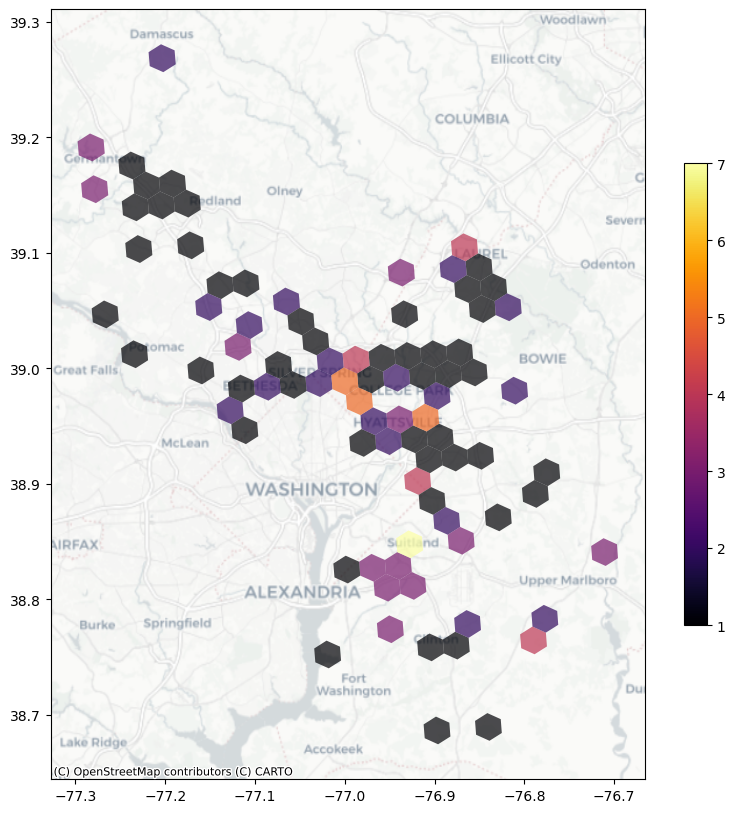

In [39]:
ax = wssc_alerts_agg.plot(
    column='val',
    figsize=(10, 10),
    cmap='inferno',
    alpha=0.7,
    legend=True,
    legend_kwds={'shrink': 0.6}
)
cx.add_basemap(ax, crs=wssc_alerts_agg.crs, source=cx.providers.CartoDB.Positron, zoom=10)